# Titanic Survival Prediction

Machine Learning project using the Titanic dataset to predict passenger survival.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

##step 1:Load Dataset
we load the Titanic training and testing datasets using pandas

In [2]:
#load datasets
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
#display first 5 rows
print(train_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


##step 2:understand Dataset
we check-
-no of rows and columns
-column names
-dataset information

In [3]:
#shape of dataset
print(train_df.shape)
#column names
print(train_df.columns)
#datset information
print(train_df.info())

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


## Step 3: Check Missing Values

We identify missing values in the dataset.

In [4]:
#missing values
print(train_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


##step 4: Survival Analysis
We analyze how many passengers survived and how many did not survive

In [5]:
#survival count
print(train_df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


##step 5:Data Visualization
we visiualize the survival count using a bar graph.

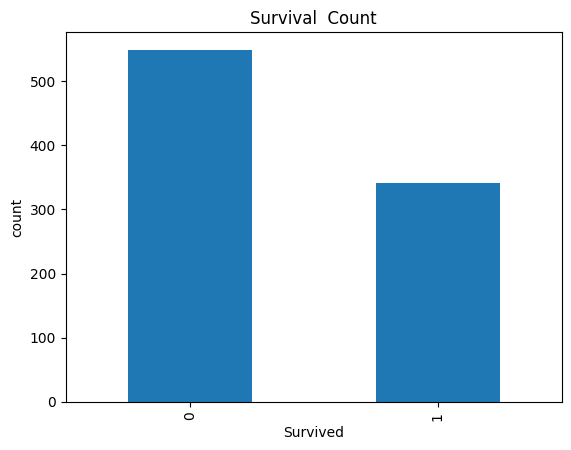

In [6]:
#survival graph
train_df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival  Count")
plt.xlabel("Survived")
plt.ylabel("count")
plt.show()

## Step 6: Data Cleaning

We handle missing values in the dataset.

In [7]:
#fill missing age values
train_df["Age"]=train_df["Age"].fillna(train_df["Age"].median())
test_df["Age"]=test_df["Age"].fillna(test_df["Age"].median())
#fill missing embarked values
train_df["Embarked"]=train_df["Embarked"].fillna(
    train_df["Embarked"].mode()[0]
)
#checlk missing values again
print(train_df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


##step 7: Convert categorial data
Machine Learning models cannot understand text values directly.
we convert:
-male/female->numbers
-embarked values->numbers

In [8]:
#convert sex column
train_df["Sex"]=train_df["Sex"].map({
    "male":0,
    "female":1
})
test_df["Sex"]=test_df["Sex"].map({
    "male":0,
    "female":1
})
train_df["Embarked"]=train_df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

##step 8:select features
we select important columns for prediction

In [9]:
#features
X=train_df[["Pclass","Sex","Age","Fare"]]
##target
y=train_df["Survived"]
print(X.head())

   Pclass  Sex   Age     Fare
0       3    0  22.0   7.2500
1       1    1  38.0  71.2833
2       3    1  26.0   7.9250
3       1    1  35.0  53.1000
4       3    0  35.0   8.0500


##step 9:Train-Test Split
We divide the dataset into training data and testing data.

In [10]:
##split dataset
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(712, 4)
(179, 4)


##step 10:Train Machine Learning Model
We use Logistic Regression for prediction.

In [11]:
##create model
model=LogisticRegression()
##train model
model.fit(X_train,y_train)

LogisticRegression()

##step 11:Make Predictions
The trained model predicts survival outcomes.

In [12]:
##predictions
predictions=model.predict(X_test)
print(predictions[:10])


[0 0 0 1 1 1 1 0 1 1]


##step 12:Model Accuracy
We evaluate model performance using accurancy score.

In [13]:
##accuracy
accuracy=accuracy_score(y_test,predictions)
print("Accuracy:",accuracy)


Accuracy: 0.8044692737430168


##step 13:confusion matrix
A confusion matrix helps visualize correct and in coreect predictions.

In [14]:
##confusion matrix
cm=confusion_matrix(y_test,predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 15]
 [20 54]]


##conclusion
This project predicts Titanic passenger survival using Machine Learning.
##Libraries used
-Pandas
-Matplotlib
-Scikit-learn
##Machine Learning Algorithm
-Logistic Regression